In [198]:
# Importing the necessary libraries for data preprocessing
import numpy as np
import pandas as pd
import os

# Importing the libraries necessary for visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Importing the libraries necessary for creating models, data preprocessing, and evaluation.
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [189]:
# Importing data source files and saving them to dataframes. Also setting indexes on every dataframe that
# has an acceptable built-in key column, cleaning the columns, and changing their formatting to snake case.

# Credit Tier data reference
credit_tiers_df = pd.read_csv('credit_tiers.csv')
credit_tiers_df.columns = (
    credit_tiers_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)

# Personal Demographic data references 
avg_cs_by_age_df = pd.read_csv('avg_cs_by_age.csv')
avg_cs_by_age_df.columns = (
    avg_cs_by_age_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)


avg_cs_by_marital_df = pd.read_csv('avg_cs_by_marital.csv')
avg_cs_by_marital_df.columns = (
    avg_cs_by_marital_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)

avg_cs_by_state_df = pd.read_csv('avg_cs_by_state.csv')
avg_cs_by_state_df.columns = (
    avg_cs_by_state_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)


avg_cs_by_gender_df = pd.read_csv('avg_cs_by_gender.csv')
avg_cs_by_gender_df.columns = (
    avg_cs_by_gender_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)


avg_cs_by_race_df = pd.read_csv('avg_cs_by_race.csv')
avg_cs_by_race_df.columns = (
    avg_cs_by_race_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)


avg_cs_by_education_df = pd.read_csv('avg_cs_by_education.csv')
avg_cs_by_education_df.columns = (
    avg_cs_by_education_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)

# Financial Demographic data references
avg_cs_by_individual_income_df = pd.read_csv('avg_cs_by_individual_income.csv')
avg_cs_by_individual_income_df.columns = (
    avg_cs_by_individual_income_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)

avg_ct_by_city_df = pd.read_csv('avg_ct_by_city.csv')
avg_ct_by_city_df.columns = (
    avg_ct_by_city_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)


avg_income_by_city_df = pd.read_csv('avg_income_by_city.csv')
avg_income_by_city_df.columns = (
    avg_income_by_city_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
)



In [190]:
# Cleaning data: Changing data types as necessary, removing unecessary columns,
# Removing the missing values, and combining dataframes as needed.

# Additionally, splitting the credit_tier's "range" column to two seperate columns: "min_score" and "max_score"
credit_tiers_df[["min_score", "max_score"]] = (credit_tiers_df["range"].str.split("-", expand=True))
credit_tiers_df["min_score"] = credit_tiers_df["min_score"].astype(int)
credit_tiers_df["max_score"] = credit_tiers_df["max_score"].astype(int)
credit_tiers_df = credit_tiers_df.drop("range",axis = 1)

avg_cs_by_age_df = avg_cs_by_age_df.drop("change",axis = 1)
avg_cs_by_age_df = avg_cs_by_age_df.drop("2024",axis = 1)
avg_cs_by_age_df = avg_cs_by_age_df.rename(columns={"2025": "credit_score"})

avg_cs_by_state_df = avg_cs_by_state_df.drop("change_(points)", axis = 1)
avg_cs_by_state_df = avg_cs_by_state_df.drop("2024",axis = 1)
avg_cs_by_state_df = avg_cs_by_state_df.rename(columns={"2025": "credit_score"})

avg_cs_by_gender_df =avg_cs_by_gender_df.drop("difference_for_women", axis = 1)
avg_cs_by_gender_df = avg_cs_by_gender_df.rename(columns={"debt/credit_metric": "credit_score"})

avg_cs_by_race_df = avg_cs_by_race_df.drop(["vantagescore_range", "fico_score_range"], axis = 1)
avg_cs_by_race_df = avg_cs_by_race_df[avg_cs_by_race_df['race'] != 'All Communities']

avg_cs_by_education_df = avg_cs_by_education_df.drop(["rank", "range"], axis = 1)
avg_cs_by_education_df = avg_cs_by_education_df.rename(columns={'median_credit_score': 'credit_score'})
# Summarizing all the doctorate degrees into one average. 
avg_cs_by_education_df['degree'] = avg_cs_by_education_df['degree'].replace({'Doctor of Pharmacy': 'Doctorate', 'Juris Doctor (JD)': 'Doctorate',
                                                                               'Doctor of Philosophy (PhD)': 'Doctorate', 'Master of Business Administration (MBA)': 'MBA'})
# Replacing the 3 seperate Doctorate scores with a row containing the average instead
avg_dr_score = avg_cs_by_education_df.loc[avg_cs_by_education_df['degree'] == 'Doctorate', 'credit_score'].mean()
avg_cs_by_education_df = avg_cs_by_education_df[avg_cs_by_education_df['degree'] != 'Doctorate']
new_row = pd.DataFrame({'degree': ['Doctorate'], 'credit_score': [avg_dr_score]})
avg_cs_by_education_df = pd.concat([avg_cs_by_education_df, new_row], ignore_index=True)
avg_cs_by_education_df["credit_score"] = avg_cs_by_education_df["credit_score"].astype(int)

avg_cs_by_individual_income_df = avg_cs_by_individual_income_df.drop(["average_credit_score,_2022", "average_credit_card_balance_-_2023", "state"], axis = 1)
avg_cs_by_individual_income_df = avg_cs_by_individual_income_df.rename(columns={"median_individual_income_-_2023": "median_income", "average_credit_score,_2023": "avg_credit_score"})
avg_cs_by_individual_income_df["median_income"] = (
    avg_cs_by_individual_income_df["median_income"]
        .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float))

avg_ct_by_city_df = avg_ct_by_city_df.rename(columns={"geoid_name": "city", "sitsinstate": "state", "ci_range": "credit_tier"})
avg_ct_by_city_df['city_state'] = avg_ct_by_city_df['city'] + '_' + avg_ct_by_city_df['state']
avg_ct_by_city_df = avg_ct_by_city_df[["city_state", "credit_tier"]]
avg_ct_by_city_df = avg_ct_by_city_df[avg_ct_by_city_df['credit_tier'] != 'N/A']
avg_ct_by_city_df = avg_ct_by_city_df.dropna()

avg_income_by_city_df = avg_income_by_city_df.rename(columns={"geoid_name": "city", "sitsinstate": "state", "mhhinc": "avg_income"})
avg_income_by_city_df['city_state'] = avg_income_by_city_df['city'] + '_' + avg_income_by_city_df['state']
avg_income_by_city_df = avg_income_by_city_df[["city_state", "avg_income"]]
avg_income_by_city_df = avg_income_by_city_df[avg_income_by_city_df['avg_income'] != 'N/A']
avg_income_by_city_df = avg_income_by_city_df.dropna()

# Merging both the avg_ct_by_city_df and avg_income_by_city_df based on the city_state column. This will allow us to obtain a significant volume of credit tier data 
# per average household income. This will be used for our main ML model later
avg_ct_by_household_income = pd.merge(avg_ct_by_city_df, avg_income_by_city_df, on='city_state')
avg_ct_by_household_income = avg_ct_by_household_income.dropna()

# The credit tiers used in the data source align with the tiers the credit bureaus use. Replacing the phrasing to align with the standard tier names to make the data
# easier to follow and more familiar to the audience:
avg_ct_by_household_income['credit_tier'] = avg_ct_by_household_income['credit_tier'].replace({'Credit Assured': 'Exceptional', 'Credit Likely': 'Very Good',
                                                                               'Mid-Tier': 'Good', 'Credit At Risk': 'Fair', 'Credit Insecure': 'Poor'})


# No cleaning was needed for: avg_cs_by_marital_df, avg_cs_by_race_df

In [149]:
# Creating a standardized version of each dataframe, then combining them. Since each of these tables do not have 
# a significant amount of data, I will be combining that data to one comparison table.

standardized_age_df = avg_cs_by_age_df
standardized_age_df = standardized_age_df.rename(columns={"generation_(age)": "category", "credit_score": "avg_credit_score"})
standardized_age_df["feature"] = "age"
standardized_age_df = standardized_age_df[["feature", "category", "avg_credit_score"]]

standardized_marital_df = avg_cs_by_marital_df
standardized_marital_df = standardized_marital_df.rename(columns={"marital_status": "category","credit_score": "avg_credit_score"})
standardized_marital_df["feature"] = "marital_status"
standardized_marital_df = standardized_marital_df[["feature", "category", "avg_credit_score"]]

standardized_edu_df = avg_cs_by_education_df
standardized_edu_df = standardized_edu_df.rename(columns={"degree": "category", "credit_score": "avg_credit_score"})
standardized_edu_df["feature"] = "education"

standardized_state_df = avg_cs_by_state_df
standardized_state_df = standardized_state_df.rename(columns={"state": "category","credit_score": "avg_credit_score"})
standardized_state_df["feature"] = "state"
standardized_state_df = standardized_state_df[["feature", "category", "avg_credit_score"]]

standardized_gender_df = avg_cs_by_gender_df
standardized_gender_df = standardized_gender_df.melt(var_name="category", value_name="avg_credit_score")
standardized_gender_df["feature"] = "gender"
standardized_gender_df = standardized_gender_df[["feature", "category", "avg_credit_score"]]
standardized_gender_df = standardized_gender_df[standardized_gender_df['avg_credit_score'] != 'Average credit score']

standardized_race_df = avg_cs_by_race_df
standardized_race_df = standardized_race_df.rename(columns={"race": "category", "average_score": "avg_credit_score"})
standardized_race_df["feature"] = "race"
standardized_race_df = standardized_race_df[["feature", "category", "avg_credit_score"]]

standardized_income_df = avg_cs_by_individual_income_df
standardized_income_df = standardized_income_df.rename(columns={"median_income": "category","avg_credit_score": "avg_credit_score"})
standardized_income_df["feature"] = "income"

# Combining the above data into one comparison table
comparison_df = pd.concat([standardized_age_df, standardized_marital_df, standardized_edu_df, standardized_state_df, 
                           standardized_gender_df,standardized_race_df, standardized_income_df], ignore_index=True)
comparison_df = comparison_df.dropna()
comparison_df["avg_credit_score"] = comparison_df["avg_credit_score"].astype(int)

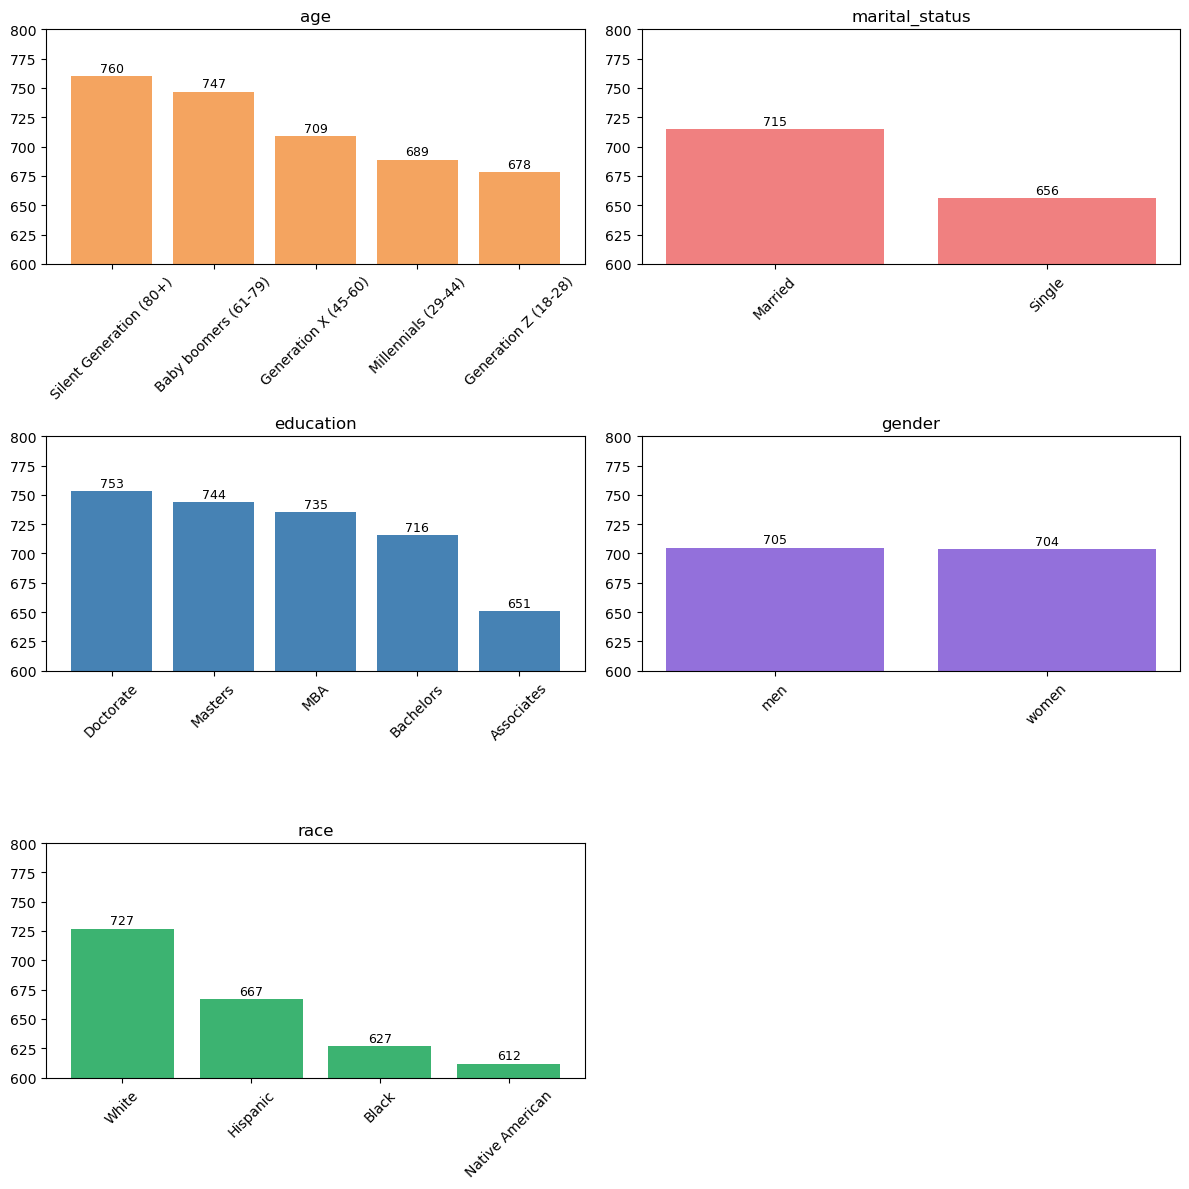

In [150]:
# Creating bar subplots that display the average credit score for certain demographics

# Sorting the credit_score data in descending order
comparison_df = comparison_df.sort_values(by=["avg_credit_score"],ascending=[False])

# Only displaying the features that we have limitted data on. These, on their own, will not be useful for modelling. 
selected_features = ["age", "marital_status", "education", "gender", "race"]

filtered_df = comparison_df[comparison_df["feature"].isin(selected_features)]

# Setting colors for each feature
colors = {"age": "sandybrown",
    "marital_status": "lightcoral",
    "education": "steelblue",
    "gender": "mediumpurple",
    "race": "mediumseagreen"}

# Creating subplot size
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Looping through each feature
for i, feature in enumerate(selected_features):
    ax = axes[i]
    subset = filtered_df[filtered_df["feature"] == feature]
    bars = ax.bar(
        subset["category"],
        subset["avg_credit_score"],
        color=colors[feature]
        )
    
    ax.set_title(feature)
    
    # Limitting the y-axis since we do not have values above 800 or below 600
    ax.set_ylim(600, 800)
    ax.tick_params(axis='x', rotation=45)

    # Adding in data labels above the bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Since we are only displaying an odd number of tables, turning off the  6th plot
for j in range(len(selected_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [191]:
# Encoding the data from our avg_ct_by_household_income dataframe in order to assign numerical numbers to the existing credit tiers. 
tier_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Exceptional": 4
}

avg_ct_by_household_income["credit_tier_encoded"] = (avg_ct_by_household_income["credit_tier"].map(tier_map))

In [193]:
# Creating a linear regression model to evaluate how credit score is impacted by household income: 
X = avg_ct_by_household_income[["avg_income"]]
y = avg_ct_by_household_income["credit_tier_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1000)

# Scaling the data using StandardScaler due to a convergence warning I kept receiving 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [197]:
# Evaluating the model's accuracy and creating a classification report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred))

Accuracy: 51.41%

              precision    recall  f1-score   support

           0       0.36      0.70      0.47       646
           1       0.00      0.00      0.00       514
           2       0.00      0.00      0.00       523
           3       0.00      0.00      0.00       665
           4       0.58      0.93      0.72      1836

    accuracy                           0.51      4184
   macro avg       0.19      0.32      0.24      4184
weighted avg       0.31      0.51      0.39      4184



C:\Users\cmfra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cmfra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cmfra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# The above results tell us that the logistic Regression model struggled to predict the "Good", "Fair", and "Very Poor" ratings. This 
# makes sense since the dataset mostly identified cities with the "Poor" and "Exception" credit tiers. 

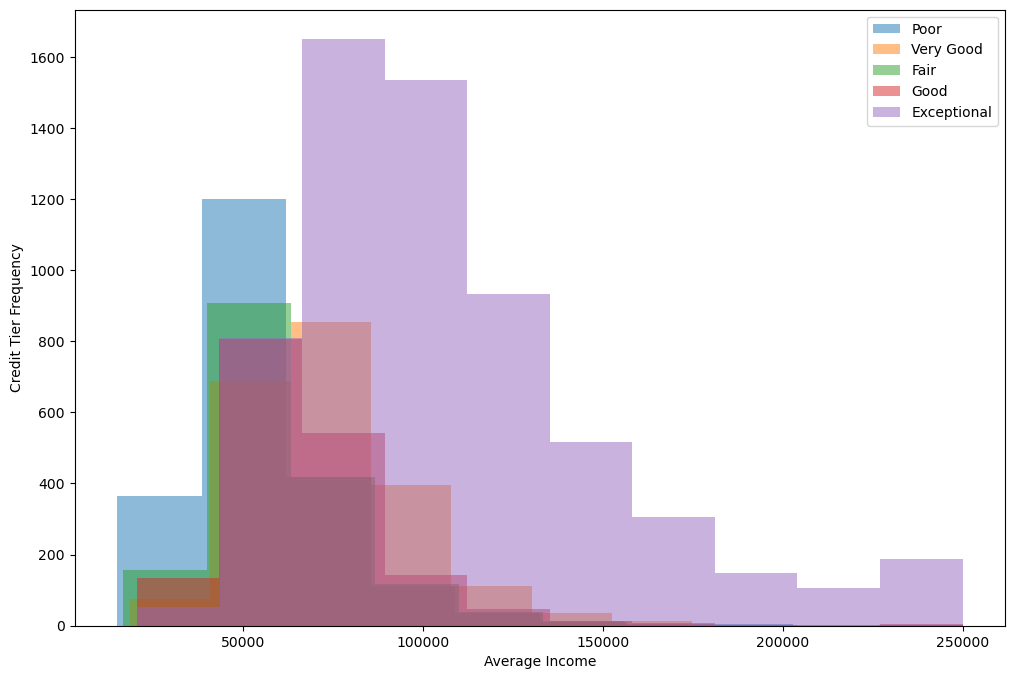

In [183]:
# Visualizing the Logistic Regression Model
plt.figure(figsize=(12,8))

# Looping through each credit tier option
for tier in avg_ct_by_household_income["credit_tier"].unique():
    subset = avg_ct_by_household_income[avg_ct_by_household_income["credit_tier"] == tier]
    plt.hist(subset["avg_income"], alpha=0.5, label=tier)

plt.legend()
plt.xlabel("Average Income")
plt.ylabel("Credit Tier Frequency")

plt.show()

In [215]:
# Attempting to use Random Forest instead:
X = avg_ct_by_household_income[["avg_income"]]
y = avg_ct_by_household_income["credit_tier_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=1000, stratify=y)
credit_tier_rf_model = RandomForestClassifier(n_estimators=200, random_state=1000, class_weight="balanced")

credit_tier_rf_model.fit(X_train, y_train)

y_pred = credit_tier_rf_model.predict(X_test)

In [216]:
# Evaluating the performance of the Random Forest model: 

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

# This tells us that the highest incomes are strongly related to 'Exceptional' credit ratings, but every other level of the credit tier is hard to predict
# because multiple income levels are commonplace on each tier. 

Accuracy: 39.65%


Classification Report:

              precision    recall  f1-score   support

           0       0.32      0.33      0.32       647
           1       0.19      0.23      0.21       497
           2       0.16      0.17      0.17       511
           3       0.17      0.17      0.17       655
           4       0.65      0.60      0.63      1874

    accuracy                           0.40      4184
   macro avg       0.30      0.30      0.30      4184
weighted avg       0.41      0.40      0.40      4184

[[ 211  140   86  100  110]
 [ 124  114   68   86  105]
 [  96   90   87   85  153]
 [  95   92  115  114  239]
 [ 134  153  185  269 1133]]


In [218]:
# Exporting the editted dateframes:
credit_tiers_df.to_csv('output_credit_tiers_df.csv', index=False)
comparison_df.to_csv('output_comparison_df.csv', index=False)
avg_ct_by_household_income.to_csv('output_avg_ct_by_household_income.csv', index=False)